<a href="https://colab.research.google.com/github/bharadhwajtorati/optimal-portfolio-allocation/blob/main/Another_copy_of_Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

enter no.of stocks:4
enter stock 1:tcs
enter stock 2:ongc
enter stock 3:reliance
enter stock 4:hdfcbank
assets selected = ['TCS.NS', 'ONGC.NS', 'RELIANCE.NS', 'HDFCBANK.NS']
enter value 0f gamma in 1-50(more gama less risk and less expected return):5


/tmp/ipython-input-252991696.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(stocks, period="3y") #downlaod data of 3yrs
[*********************100%***********************]  4 of 4 completed


Ticker,HDFCBANK.NS,ONGC.NS,RELIANCE.NS,TCS.NS
Date,,,,
2023-01-02,783.677856,128.953857,1175.889648,2986.108643
2023-01-03,788.802368,128.182465,1167.284668,3031.796143
2023-01-04,774.704163,125.353966,1149.709595,3034.817871
2023-01-05,769.724060,125.568230,1147.655396,3031.567627
2023-01-06,767.173889,126.296814,1158.086304,2940.422363
...,...,...,...,...
2025-12-25,997.200012,233.770004,1558.199951,3319.000000
2025-12-26,992.099976,234.529999,1559.199951,3280.000000
2025-12-29,991.700012,234.820007,1545.599976,3251.500000


'annual expected return of each stock:'

,0
Ticker,
HDFCBANK.NS,0.079891
ONGC.NS,0.211791
RELIANCE.NS,0.098387
TCS.NS,0.024185


'covariance matrix(annual):'

Ticker,HDFCBANK.NS,ONGC.NS,RELIANCE.NS,TCS.NS
Ticker,,,,
HDFCBANK.NS,0.034379,0.012352,0.013493,0.005192
ONGC.NS,0.012352,0.078877,0.026215,0.011791
RELIANCE.NS,0.013493,0.026215,0.040011,0.010857
TCS.NS,0.005192,0.011791,0.010857,0.038657


'optimal weights for given constraints'

,weights
HDFCBANK.NS,0.371174
ONGC.NS,0.268482
RELIANCE.NS,0.184078
TCS.NS,0.176266


expected portfolio return: 0.1089
volatility           : 0.14958536536358652


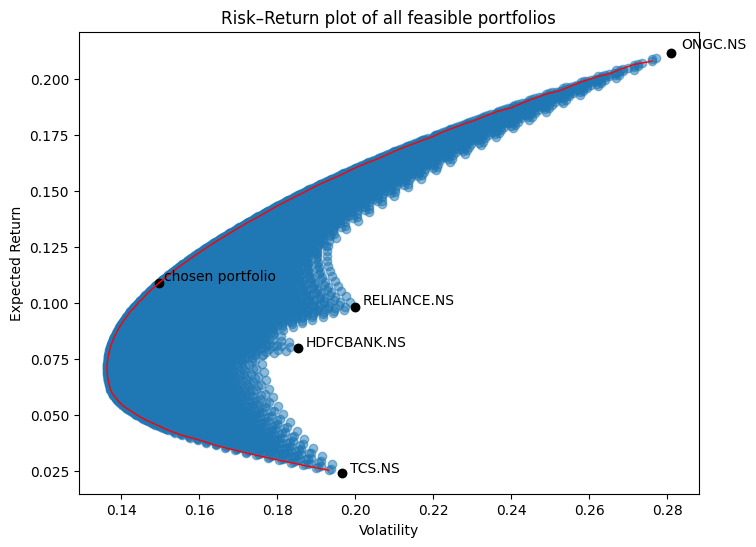

In [ ]:
import cvxpy as cp
import pandas as pd
import numpy as np
import yfinance as yf
from math import sqrt
import matplotlib.pyplot as plt

#tacking input from user
stocks=[]
n=int(input('enter no.of stocks:'))
print
for i in range(1,n+1):
  x=input(f'enter stock {i}:')
  x=x.upper()+'.NS'
  stocks.append(x)
print('assets selected =',stocks)
gamma=float(input('enter value 0f gamma in 1-50(more gama less risk and less expected return):'))


#importing price data of selected stocks
prices = yf.download(stocks, period="3y") #downlaod data of 3yrs
prices = prices.xs('Close', axis=1, level=0)
prices.dropna()
stocks=list(prices.keys())
display(prices)


#calculating annual expected return of each stock,cov matrix
log_returns=((prices/prices.shift(1)).dropna()).apply(lambda x : np.log(x))
expected_return=log_returns.mean()*252
cov_matrix=log_returns.cov()*252
display("annual expected return of each stock:",expected_return)
display('covariance matrix(annual):',cov_matrix)

#finding optimal solution using cvxpy
weights=cp.Variable(n)
rtn=expected_return.values @ weights
var=cp.quad_form(weights, cov_matrix)
#constraints
constraints = [cp.sum(weights)==1,weights>=0]
#objective
obj=rtn-gamma*var
problem=cp.Problem(cp.Maximize(obj),constraints)
problem.solve()

#printing optimal weights for given constraints
weights=list(weights.value)
display('optimal weights for given constraints',pd.DataFrame(data=weights,index=stocks,columns=['weights']))
print('expected portfolio return:',(rtn.value).round(4))
print('volatility           :',sqrt(var.value))


#ploting this portfolio in return-volatility plot along with all possible portfolios
#all possibilities
step=0.02
weights=[]
if n==3:
 for w1 in np.arange(0,1+step,step):
   for w2 in np.arange(0,1+step,step):
     if w1+w2<=1:
       weights.append([w1,w2,1-w1-w2])
if n==4:
  for w1 in np.arange(0,1+step,step):
   for w2 in np.arange(0,1+step,step):
    for w3 in np.arange(0,1+step,step):
      if w1+w2+w3<=1:
       weights.append([w1,w2,w3,1-w1-w2-w3])
# here we can write code similarly for different n but taking much time as n increases
#idk how to write code for all n
weights=np.array(weights)

portfolio_returns = []
portfolio_volatility = []
for w in weights:
    ret = np.dot(w,expected_return)
    vr = np.dot(w,np.dot(w,cov_matrix))
    portfolio_returns.append(ret)
    portfolio_volatility.append(np.sqrt(vr))
portfolio_df = pd.DataFrame(weights, columns=np.arange(n))
portfolio_df["Return"] = portfolio_returns
portfolio_df["Volatility"] = portfolio_volatility
#ploting
plt.figure(figsize=(8,6))
plt.scatter(
    portfolio_df["Volatility"],
    portfolio_df["Return"],
    alpha=0.5
)
plt.xlabel("Volatility")
plt.ylabel("Expected Return")
plt.title("Risk–Return plot of all feasible portfolios")


#some particulars
expected_return.loc['chosen portfolio']=rtn.value
asset_volatility=log_returns.std()*sqrt(252)
asset_volatility.loc['chosen portfolio']=sqrt(var.value)
stocks.append('chosen portfolio')
special=pd.DataFrame(index=stocks,columns=[])
special['volatility']=asset_volatility
special['return']=expected_return
#ploting
plt.scatter(special['volatility'],special['return'],alpha=1,color='black')
for asset in special.index:
    plt.text(asset_volatility[asset]*1.01, expected_return[asset]*1.01, asset)

#Efficient Frontier
bins = np.linspace(
    portfolio_df["Return"].min(),
    portfolio_df["Return"].max(),
    100
)
frontier_risk = []
frontier_return = []

for i in range(len(bins)-1):
    mask = (portfolio_df["Return"] >= bins[i]) & (portfolio_df["Return"] < bins[i+1])
    subset = portfolio_df[mask]

    if len(subset) > 0:
        min_row = subset.loc[subset["Volatility"].idxmin()]
        frontier_risk.append(min_row["Volatility"])
        frontier_return.append(min_row["Return"])
plt.plot(frontier_risk, frontier_return, color="red", linewidth=1)


plt.show()


